In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1=pd.read_csv('/content/drive/MyDrive/MLT /Copy of i1.csv')
df2=pd.read_csv('/content/drive/MyDrive/MLT /Copy of i2.csv')

In [ ]:
df=df1.merge(df2,how='outer')

In [ ]:
df.tail()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
15616,2023-09-19,2023-09-19 22:03:44,28389,Kulcha,55.0,1.0,55.0,0.0,2.76,57.76,16.0,biller,0,NaN,Indian Breads,NaN
15617,2023-09-19,2023-09-19 22:03:44,28389,Mineral Water,20.0,2.0,40.0,0.0,2.00,42.00,16.0,biller,0,NaN,Deserts & Mocktails,NaN
15618,2023-09-19,2023-09-19 22:03:44,28389,Mushroom Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN
15619,2023-09-19,2023-09-19 22:03:44,28389,Paneer Butter Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN
15620,2023-09-19,2023-09-19 22:03:44,28389,Parota,30.0,4.0,120.0,0.0,6.00,126.00,16.0,biller,0,NaN,Indian Breads,NaN


In [ ]:
df.shape

(15621, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [ ]:
df.drop(['Table No.','Server Name','Covers','Variation','HSN'],axis=1)
#axis=1 column
#axis=0 row

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Category
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.00,168.00,Veg Starters
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.00,126.00,NON VEG STARTERS CHICKEN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.00,315.00,Veg Gravy
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.00,126.00,Indian Breads
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.00,168.00,NON VEG BRIYANI & RICE
...,...,...,...,...,...,...,...,...,...,...,...
15616,2023-09-19,2023-09-19 22:03:44,28389,Kulcha,55.0,1.0,55.0,0.0,2.76,57.76,Indian Breads
15617,2023-09-19,2023-09-19 22:03:44,28389,Mineral Water,20.0,2.0,40.0,0.0,2.00,42.00,Deserts & Mocktails
15618,2023-09-19,2023-09-19 22:03:44,28389,Mushroom Masala,150.0,1.0,150.0,0.0,7.50,157.50,Veg Gravy
15619,2023-09-19,2023-09-19 22:03:44,28389,Paneer Butter Masala,150.0,1.0,150.0,0.0,7.50,157.50,Veg Gravy


In [ ]:
df.shape

(15621, 16)

In [ ]:
a=df['Final Total'].sum()

In [ ]:
b=df['Invoice No.'].nunique()

In [ ]:
aov=a/b

In [ ]:
aov

np.float64(486.70256243654825)

In [ ]:
m=df.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]

<Axes: xlabel='Item Name', ylabel='Qty.'>

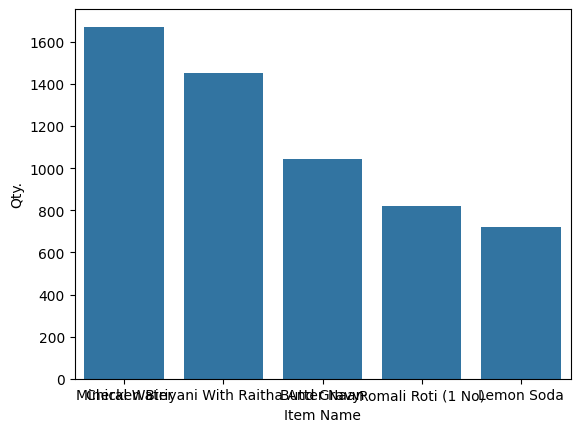

In [ ]:
sns.barplot(m)

<Axes: xlabel='Item Name'>

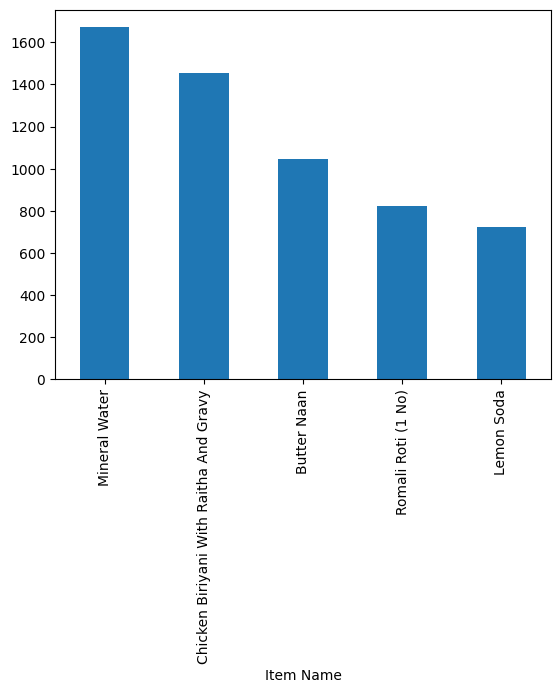

In [ ]:
m.plot(kind='bar')

In [ ]:
df.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False)[0:5]

,Final Total
Item Name,
Chicken Biriyani With Raitha And Gravy,240730.96
Chicken Fried Rice,119347.20
Butter Naan,65387.74
Thandoor Chicken Half,53185.83
Paneer Butter Masala,49581.22


In [ ]:
df[df['Date']=='2023-09-15']['Final Total'].sum()

np.float64(21042.02)

In [ ]:
df[(df['Date']=='2023-09-15')&(df['Item Name']=='chicken Noodles')]['Qty.'].sum()

np.float64(0.0)

In [ ]:
df[df['Final Total']>=2000]['Invoice No.']

,Invoice No.
1039,23827
4694,24987
6103,25427
6117,25434
11405,27210
14772,28126


In [ ]:
j=df.groupby('Invoice No.')['Final Total'].sum()
j[j>2000]

,Final Total
Invoice No.,
23499,2533.64
23508,2011.00
23637,5644.82
23718,3517.50
23827,22638.00
...,...
28014,3013.68
28126,2887.50
28145,4078.68


In [ ]:
df[df['Final Total']==2887.50]['Invoice No.']

,Invoice No.
14772,28126


In [ ]:
df[df['Invoice No.']==28145][['Item Name','Price','Discount','Final Total']].sum()

,0
Item Name,Butter Chicken GravyButter Chicken GravyButter...
Price,2717.0
Discount,431.6
Final Total,4078.68


AttributeError: 'Axes' object has no attribute 'set_xtricks'

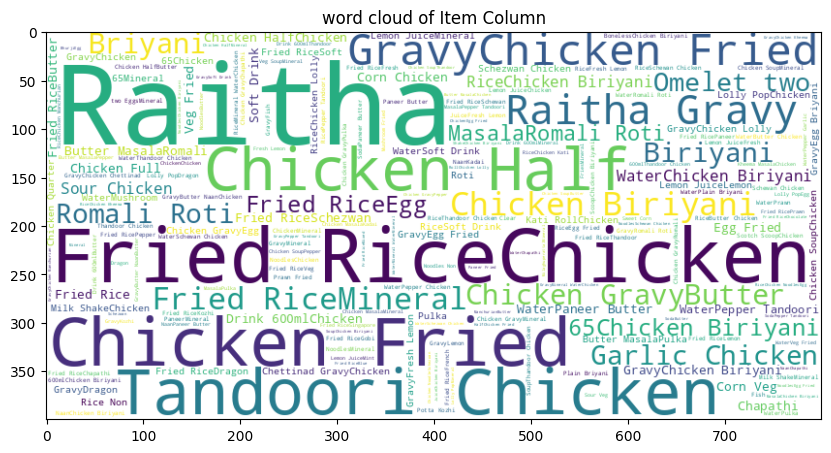

In [ ]:
from wordcloud import WordCloud
text=''.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig, ax = plt.subplots (figsize=(10,6))
ax.imshow(wordcloud,interpolation='bilinear')
ax.set_title ('word cloud of Item Column')
ax.set_xtricks([])
ax.set_ytricks([])
plt.show()


In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Item Name'].dropna().astype(str).values)

wordcloud=WordCloud(background_color='white', width=700, height=500).generate(text)
ax.set_xticks([])
ax.set_yticks([])
fig, ax=plt.subplots(figsize=(10, 6))
ax.imshow(wordcloud, interpolation='antialiased')
plt.show()

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Item Name'].dropna().astype(str).values)

wordcloud=WordCloud(background_color='white', width=700, height=500).generate(text)
ax.set_xticks([])
ax.set_yticks([])
fig, ax=plt.subplots(figsize=(10, 6))
ax.imshow(wordcloud, interpolation='spline36')
plt.show()
